# Análisis de Datos - Trabajo Práctico Integrador - Parte 2

#### **Integrantes:**
* Daniela Putrino
* Dimas Torres

### 1. Introducción y Motivación

En esta segunda parte del trabajo práctico, vamos a continuar con el análisis del dataset de registros meteorológicos del Servicio Meteorológico Nacional (SMN) de Argentina. El objetivo es preparar los datos para el entrenamiento de un modelo de Machine Learning. Para ello, aplicaremos técnicas de preprocesamiento, limpieza, ingeniería de características y reducción de dimensionalidad que vimos en clase.

**Incorporando la devolución del TP1:** Agradecemos la devolución recibida sobre la primera parte. Tomaremos en cuenta los puntos de mejora sugeridos:

1.  **Profundizaremos la interpretación de los resultados**, especialmente en el análisis de datos faltantes, justificando por qué ciertas variables podrían faltar de forma conjunta (como las de viento) o hipotetizando sobre las causas de la falta de datos en otras (como la presión atmosférica).
2.  **Revisaremos los comentarios** para asegurar que las conclusiones se deriven directamente de las visualizaciones presentadas.
3.  **Agregaremos un análisis por regiones**, como fue sugerido, para segmentar las estaciones y enriquecer el análisis exploratorio antes de pasar a la etapa de preprocesamiento para ML.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA, KernelPCA

# Configuramos seaborn para un mejor estilo en los gráficos
sns.set_theme(style="whitegrid")

### 2. Carga y Análisis Exploratorio Adicional

In [5]:
# Cargar el dataset que preparamos en la parte 1
df = pd.read_csv('SMN_data/df_ok.csv')

# Renombrar columnas para que sean más fáciles de manejar
df.rename(columns={
    'TEMP (°C)': 'TEMP',
    'HUM (%)': 'HUM',
    'PNM (hPa)': 'PNM',
    'DD (g)': 'DD',
    'FF (km/h)': 'FF'
}, inplace=True)

df.head()

,TEMP,HUM,PNM,DD,FF,ALTURA,LAT,LON,HORA_sen,HORA_cos,...,PROV_NEUQUEN,PROV_RIO NEGRO,PROV_SALTA,PROV_SAN JUAN,PROV_SAN LUIS,PROV_SANTA CRUZ,PROV_SANTA FE,PROV_SANTIAGO DEL ES,PROV_TIERRA DEL FUEG,PROV_TUCUMAN
0,13.7,88.0,1020.2,80.0,13.0,6.0,-34.55,-58.416667,0.000000,1.000000,...,False,False,False,False,False,False,False,False,False,False
1,13.6,91.0,1019.6,80.0,11.0,6.0,-34.55,-58.416667,0.258819,0.965926,...,False,False,False,False,False,False,False,False,False,False
2,13.4,91.0,1019.3,80.0,11.0,6.0,-34.55,-58.416667,0.500000,0.866025,...,False,False,False,False,False,False,False,False,False,False
3,13.4,94.0,1018.7,80.0,13.0,6.0,-34.55,-58.416667,0.707107,0.707107,...,False,False,False,False,False,False,False,False,False,False
4,13.7,91.0,1018.2,90.0,9.0,6.0,-34.55,-58.416667,0.866025,0.500000,...,False,False,False,False,False,False,False,False,False,False


#### 2.1. Incorporando Feedback del TP1: Análisis Regional

Como se sugirió en la devolución, vamos a segmentar las estaciones por región geográfica para realizar un análisis más granular. Para esto, necesitamos la columna `PROVINCIA` que fue eliminada durante el one-hot encoding. La recuperaremos del dataset original y luego crearemos una nueva columna `REGION`.

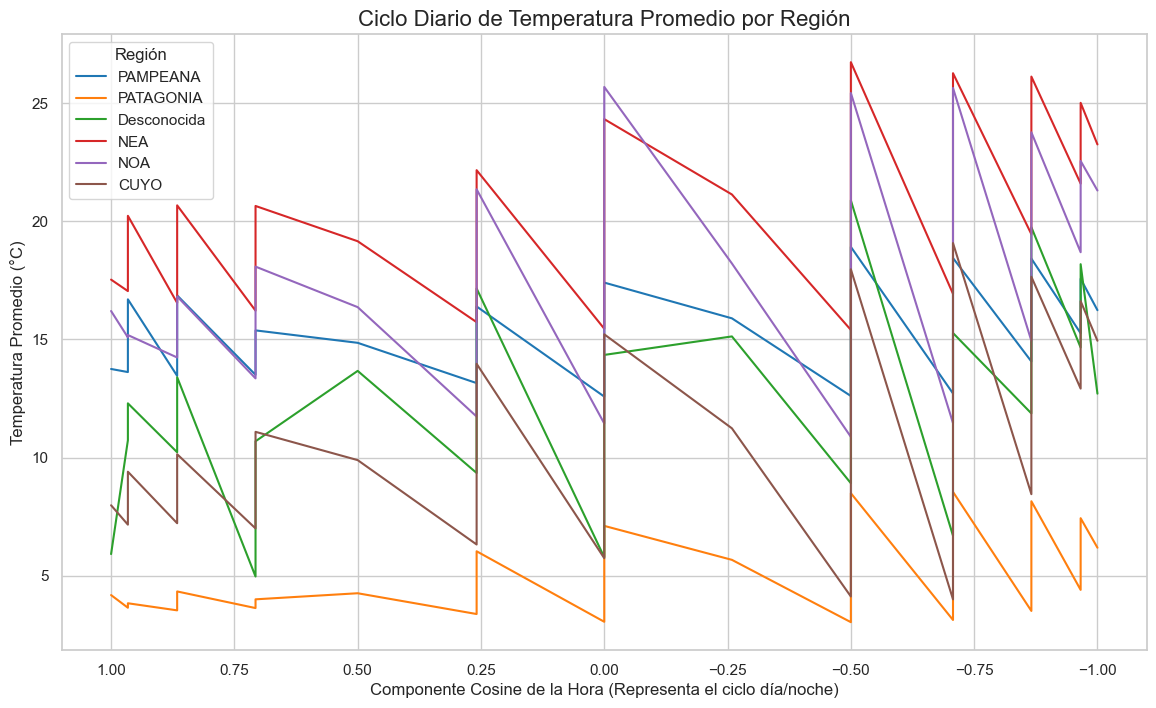

In [8]:

regiones = {
    'NOA': ['PROV_JUJUY', 'PROV_SALTA', 'PROV_TUCUMAN', 'PROV_CATAMARCA', 'PROV_LA RIOJA', 'PROV_SANTIAGO DEL ES'],
    'NEA': ['PROV_FORMOSA', 'PROV_CHACO', 'PROV_MISIONES', 'PROV_CORRIENTES', 'PROV_ENTRE RIOS'],
    'CUYO': ['PROV_SAN JUAN', 'PROV_MENDOZA', 'PROV_SAN LUIS'],
    'PAMPEANA': ['PROV_CORDOBA', 'PROV_SANTA FE', 'PROV_LA PAMPA', 'PROV_BUENOS AIRES', 'PROV_CAPITAL FEDERAL'],
    'PATAGONIA': ['PROV_RIO NEGRO', 'PROV_NEUQUEN', 'PROV_CHUBUT', 'PROV_SANTA CRUZ', 'PROV_TIERRA DEL FUEG']
}

def get_region(row):
    for region, provincias in regiones.items():
        for provincia_col in provincias:
            if provincia_col in row.index and row[provincia_col]:
                return region
    return 'Desconocida'

df_prov_cols = df.filter(like='PROV_')
df['REGION'] = df_prov_cols.apply(get_region, axis=1)

# Ahora creamos una visualización de la temperatura promedio por hora para cada región.
plt.figure(figsize=(14, 8))
# Cambiamos la paleta a 'tab10' para mejor contraste entre categorías
sns.lineplot(data=df, x='HORA_cos', y='TEMP', hue='REGION', errorbar=None, palette='tab10')
plt.title('Ciclo Diario de Temperatura Promedio por Región', fontsize=16)
plt.xlabel('Componente Cosine de la Hora (Representa el ciclo día/noche)')
plt.ylabel('Temperatura Promedio (°C)')
plt.gca().invert_xaxis() # Invertimos para que se lea como un ciclo de 24hs
plt.legend(title='Región')
plt.show()

Este gráfico nos permite comparar el comportamiento de la temperatura a lo largo del día en las distintas regiones del país. Se observa claramente que las regiones del norte (NOA, NEA) tienden a tener temperaturas más altas, mientras que la Patagonia consistentemente presenta las más bajas. Todas las regiones siguen un patrón cíclico diario similar, como es de esperar.

### 3. Preprocesamiento y Limpieza para Machine Learning

#### 3.1. Split del Dataset

Para evitar *data leakage*, lo primero que hacemos es separar nuestro dataset en conjuntos de entrenamiento y de prueba. Todas las operaciones de preprocesamiento, como la imputación de valores faltantes y el escalado, las vamos a ajustar (hacer el `fit`) **únicamente** con los datos de entrenamiento y luego las aplicaremos a ambos conjuntos. Nuestra variable a predecir es la temperatura, 'TEMP', que será nuestra `y`.

In [9]:
# Quitamos la columna REGION que fue solo para el EDA
df_ml = df.drop('REGION', axis=1)

# Separar las características (X) y la variable objetivo (y)
X = df_ml.drop('TEMP', axis=1)
y = df_ml['TEMP']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (1653, 33)
Tamaño del conjunto de prueba: (414, 33)


#### 3.2. Manejo de Valores Faltantes (Análisis Profundizado)

En el TP1 identificamos la presencia de valores faltantes. Ahora, vamos a analizarlos con mayor profundidad como se sugirió en la devolución.

- **Correlación de faltantes en `DD` y `FF`**: Observamos que cuando falta el dato de dirección del viento (`DD`), también suele faltar el de la velocidad (`FF`). Esto tiene sentido, ya que ambas mediciones provienen del mismo instrumento (anemómetro). Una falla en el sensor, un período de mantenimiento o una obstrucción afectarían a ambas variables simultáneamente. No se trata de eventos independientes, sino de una consecuencia de la forma en que se capturan los datos.

- **Faltantes en Presión Atmosférica (`PNM`)**: Los datos faltantes de presión pueden deberse a varias razones. Es posible que el barómetro de una estación específica estuviera fuera de servicio o en proceso de calibración durante esas horas. A diferencia de la temperatura o la humedad, la presión no suele variar tan bruscamente, por lo que una imputación con la mediana de los datos de entrenamiento es una estrategia razonable para no perder los registros completos.

Para el manejo de los valores faltantes, usaremos una estrategia de imputación simple. Para las variables numéricas, imputaremos los faltantes con la **mediana** de la columna, ya que es más robusta a outliers que la media.

In [11]:
# Copiamos los dataframes para no modificar los originales
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()
y_train_processed = y_train.copy()
y_test_processed = y_test.copy()

# En y_train también hay valores nulos. Los eliminamos junto a sus correspondientes filas en X_train
y_train_processed.dropna(inplace=True)
X_train_processed = X_train_processed.loc[y_train_processed.index]

# Identificar columnas numéricas y categóricas
numerical_features = X_train_processed.select_dtypes(include=np.number).columns.tolist()
categorical_features = [col for col in X_train_processed.columns if col.startswith('PROV_')]

# Creamos un pipeline para el preprocesamiento
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features)
    ],
    remainder='passthrough' # Mantenemos las columnas categóricas (one-hot encoded)
)

# Ajustamos y transformamos el conjunto de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train_processed)

# Transformamos el conjunto de prueba
X_test_processed = preprocessor.transform(X_test_processed)

# Convertimos de nuevo a DataFrame para poder visualizarlo y mantener los nombres de las columnas
X_train_processed = pd.DataFrame(X_train_processed, columns=numerical_features + categorical_features)
X_test_processed = pd.DataFrame(X_test_processed, columns=numerical_features + categorical_features)

print("Cantidad de nulos en X_train después del pipeline:", X_train_processed.isnull().sum().sum())

Cantidad de nulos en X_train después del pipeline: 0


#### 3.3. Detección y Manejo de Outliers

Vamos a visualizar las distribuciones de las principales variables numéricas para detectar outliers usando boxplots. En el TP1 mencionamos la dispersión de la variable `PNM` pero no profundizamos. Un boxplot nos ayudará a visualizar si esa dispersión se manifiesta en forma de outliers.


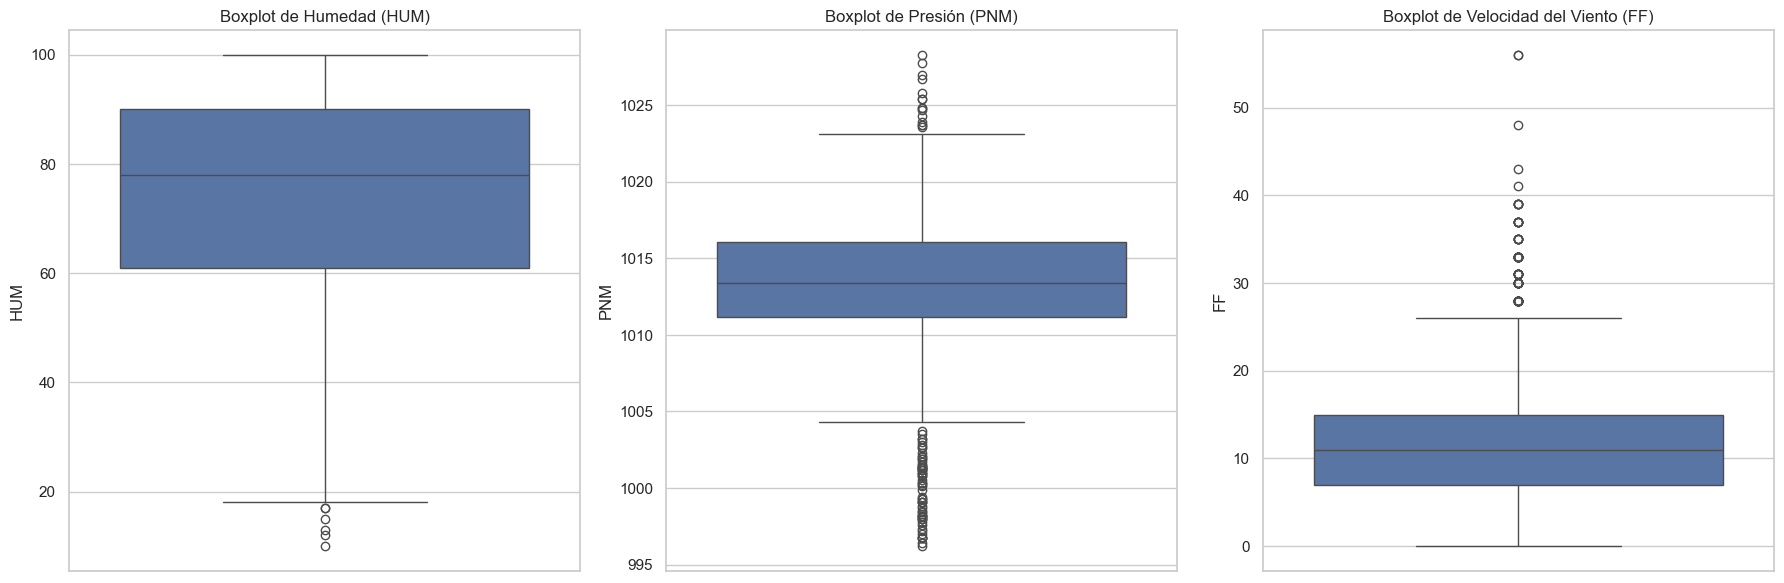

In [12]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['HUM'])
plt.title('Boxplot de Humedad (HUM)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['PNM'])
plt.title('Boxplot de Presión (PNM)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['FF'])
plt.title('Boxplot de Velocidad del Viento (FF)')

plt.tight_layout()
plt.show()

**Interpretación de los Boxplots:**

- **Humedad (`HUM`)**: Se observan algunos valores bajos que se consideran outliers. Podrían ser mediciones correctas en zonas muy secas o errores del sensor, pero no parecen extremos.
- **Presión (`PNM`)**: Muestra valores atípicos tanto altos como bajos. Estos podrían corresponder a fenómenos meteorológicos específicos (como tormentas o anticiclones fuertes) o a mediciones en estaciones de gran altitud que no fueron correctamente normalizadas a nivel del mar. Dado que la presión es una variable importante, no eliminaremos estos datos.
- **Viento (`FF`)**: Se ven varios outliers en los valores altos, que representan ráfagas de viento fuerte. Son eventos meteorológicos válidos e importantes de mantener en el dataset.

**Decisión**: Por ahora vamos a dejarlos, ya que nuestro modelo (a futuro) podría beneficiarse de aprender de estos casos extremos. El escalado con `StandardScaler` que ya aplicamos ayuda a mitigar un poco su efecto.

### 4. Feature Engineering

En la primera parte del trabajo ya realizamos una parte importante de *feature engineering*:

-   **Conversión de variables categóricas:** La variable `PROVINCIA` fue convertida a variables dummy usando *one-hot encoding*.
-   **Creación de nuevas features:** La variable `HORA` fue transformada en dos componentes sinusoidales (`HORA_sen` y `HORA_cos`) para capturar su naturaleza cíclica.

Estas transformaciones ya están incluidas en nuestro dataset `df_ok.csv`, por lo que no es necesario crear nuevas características en esta etapa.

### 5. Reducción de Dimensionalidad

Ahora tenemos un dataset con una cantidad considerable de *features* (33), en gran parte debido al *one-hot encoding* de las provincias. Vamos a explorar dos técnicas para reducir la dimensionalidad: selección de características y extracción de características.

#### 5.1. Selección de Características

Utilizaremos el método de filtro `SelectKBest` con la función de puntuación `f_regression`, que es adecuada para problemas de regresión. Esta técnica seleccionará las *k* características que tienen la mayor correlación con la variable objetivo.

In [13]:
# Seleccionar las 10 mejores características
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_processed, y_train_processed)
X_test_selected = selector.transform(X_test_processed)

# Obtener los nombres de las características seleccionadas
selected_features_mask = selector.get_support()
selected_features_names = X_train_processed.columns[selected_features_mask]

print("Características seleccionadas:")
print(list(selected_features_names))

Características seleccionadas:
['HUM', 'DD', 'LAT', 'HORA_sen', 'HORA_cos', 'PROV_FORMOSA', 'PROV_RIO NEGRO', 'PROV_SANTA CRUZ', 'PROV_SANTA FE', 'PROV_TIERRA DEL FUEG']


Las variables elegidas parecen pertenecer a distintos tipos de datos, combinando los datos meteorológicos con los regionales.

#### 5.2. Extracción de Características: PCA

Ahora, vamos a probar una técnica de extracción de características como el Análisis de Componentes Principales (PCA). PCA crea nuevas características (los componentes principales) que son combinaciones lineales de las originales y que capturan la mayor parte de la varianza del dataset.

Primero, vamos a determinar cuántos componentes necesitamos para explicar una buena parte de la varianza (por ejemplo, el 95%).

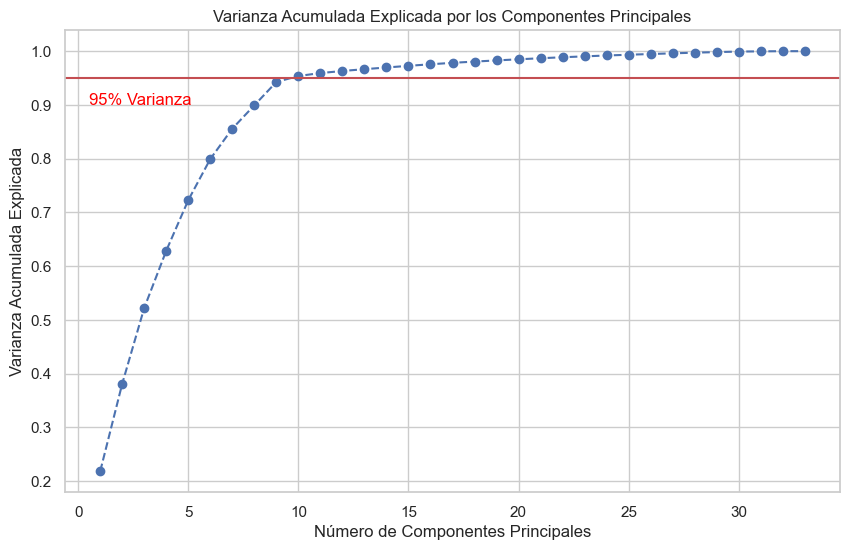

In [17]:
# Aplicar PCA
pca = PCA()
pca.fit(X_train_processed)

# Calcular la varianza acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Graficar la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('Varianza Acumulada Explicada por los Componentes Principales')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-')
plt.text(0.5, 0.9, '95% Varianza', color = 'red', fontsize=12)
plt.show()

El gráfico muestra que necesitamos aproximadamente 10 componentes para explicar el 95% de la varianza en los datos. Vamos a ver el peso de cada feature en cada uno de esos componentes

In [ ]:


# 1. Obtener los nombres de las características originales
try:
    feature_names = X_train_processed.columns
except AttributeError:
    print("Advertencia: 'X_train_processed' no es un DataFrame. Se usarán nombres genéricos.")
    feature_names = [f'Característica_{i+1}' for i in range(pca.n_features_in_)]

# 2. Crear un DataFrame con las cargas (loadings) de los componentes
#    El atributo pca.components_ contiene exactamente esta información.
df_loadings = pd.DataFrame(
    data=pca.components_,
    columns=feature_names,
    index=[f'Componente Principal {i+1}' for i in range(pca.n_components_)]
)

# 3. Filtrar para mostrar solo los primeros 10 componentes
df_top10_loadings = df_loadings.head(10)

# 4. Imprimir la tabla final, redondeando para facilitar la lectura
print("--- Aporte (Cargas) de cada Característica a los Primeros 10 Componentes Principales ---")
print(df_top10_loadings.round(3))

--- Aporte (Cargas) de cada Característica a los Primeros 10 Componentes Principales ---
                           HUM    PNM     DD     FF  ALTURA    LAT    LON  \
Componente Principal 1   0.480  0.289 -0.354 -0.260  -0.395  0.088  0.454   
Componente Principal 2   0.014  0.398  0.012 -0.376   0.509  0.512 -0.307   
Componente Principal 3   0.461 -0.190  0.353 -0.080   0.100 -0.485 -0.314   
Componente Principal 4   0.057 -0.065 -0.081 -0.087   0.072  0.014 -0.067   
Componente Principal 5   0.061  0.630  0.345  0.661  -0.013  0.006  0.073   
Componente Principal 6  -0.027  0.070  0.757 -0.470  -0.167  0.070  0.305   
Componente Principal 7  -0.043 -0.489  0.220  0.270  -0.193  0.608  0.103   
Componente Principal 8  -0.058 -0.151 -0.011  0.069   0.658 -0.169  0.682   
Componente Principal 9   0.709 -0.184  0.028  0.189   0.224  0.275 -0.042   
Componente Principal 10 -0.181 -0.076  0.002  0.003  -0.010  0.027 -0.067   

                         HORA_sen  HORA_cos  PROV_BUENOS AIRES 

Para facilitar la interpretación de esta tabla pasamos a generar un mapa de calor

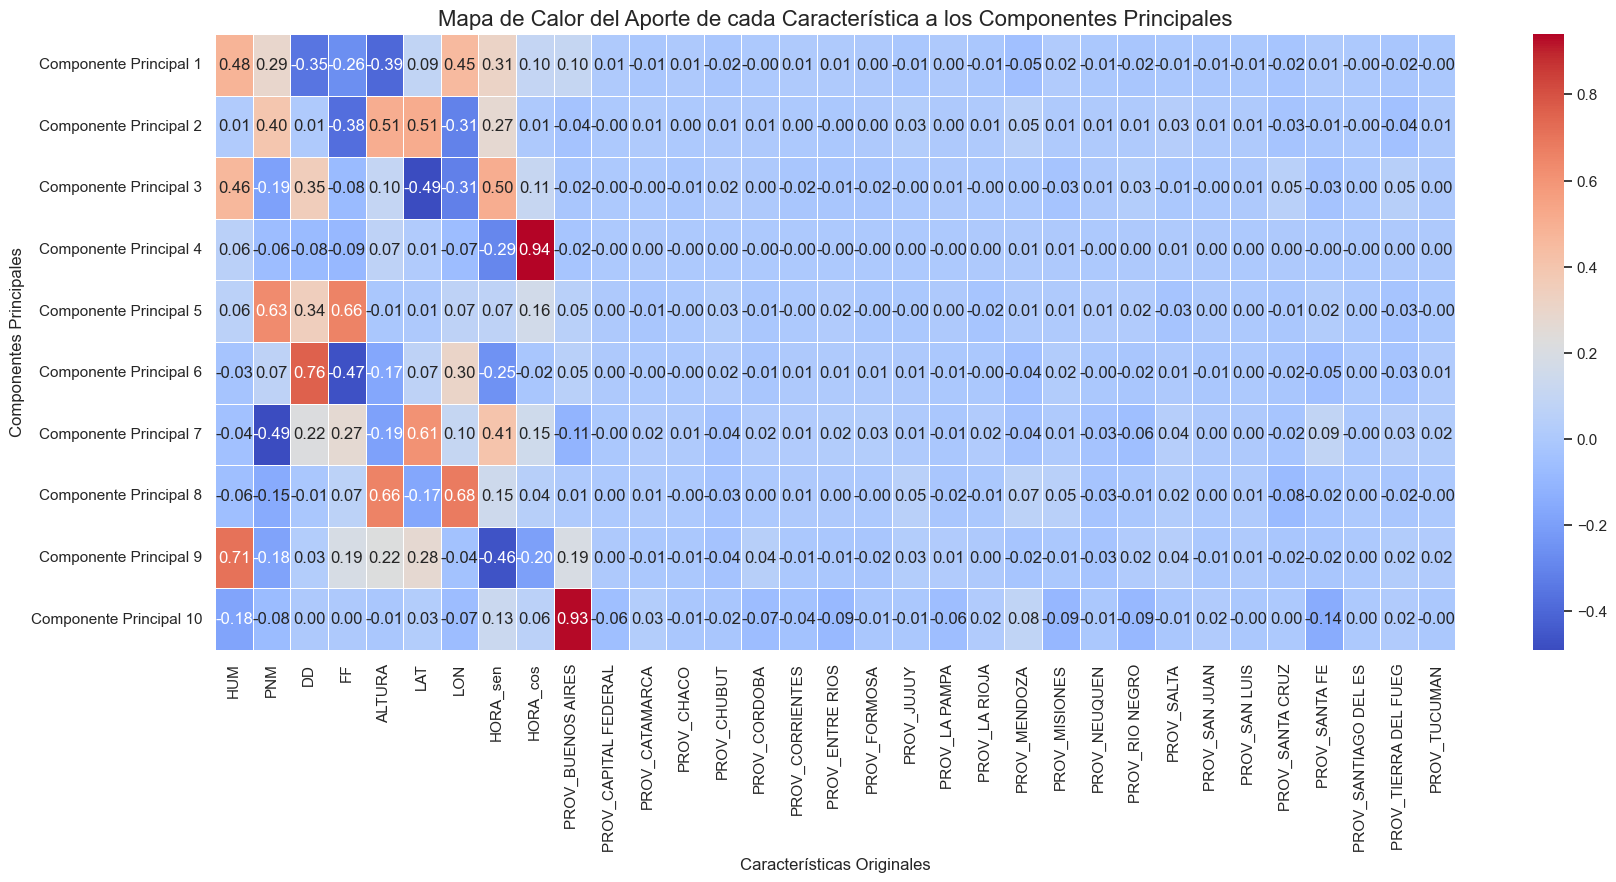

In [ ]:


plt.figure(figsize=(20, 8)) # Hacemos la figura más ancha para que quepan las etiquetas

sns.heatmap(
    df_top10_loadings, 
    cmap='coolwarm', # Una paleta de colores "divergente" ideal para valores positivos y negativos
    annot=True,      # Muestra los valores numéricos en cada celda
    fmt='.2f',       # Formatea los números a 2 decimales
    linewidths=.5    # Añade una pequeña línea entre las celdas
)

plt.title('Mapa de Calor del Aporte de cada Característica a los Componentes Principales', fontsize=16)
plt.xlabel('Características Originales', fontsize=12)
plt.ylabel('Componentes Principales', fontsize=12)
plt.show()

Como vemos en la tabla la región es redundante en relación a los features que originales, por lo tanto se pueden descartar en benedicio de una simplifiación para aplicar los modelos predictivos

#### Comparación de Técnicas de Reducción de Dimensionalidad

* **Selección de Características (SelectKBest):**
    * **Ventajas:** Es fácil de interpretar porque mantenemos las características originales. Podemos ver exactamente qué variables son las más importantes.
    * **Desventajas:** Podemos perder información que se encuentra en las combinaciones de características.
* **Extracción de Características (PCA):**
    * **Ventajas:** Captura la mayor parte de la información (varianza) del dataset con menos características. Suele funcionar muy bien como paso previo a muchos algoritmos de ML.
    * **Desventajas:** Los nuevos componentes principales son combinaciones de las características originales, por lo que perdemos la interpretabilidad directa. No sabemos qué representa cada componente en términos del problema original.

### 6. Conclusiones de la Parte 2

En esta segunda parte del trabajo, hemos preparado nuestro dataset para el entrenamiento de un modelo de machine learning.

1.  **Incorporamos el feedback del TP1**, añadiendo un análisis exploratorio por regiones y profundizando en la interpretación de los datos faltantes y las visualizaciones.
2.  **Dividimos los datos** en entrenamiento y prueba para asegurar que nuestro proceso de validación sea robusto y evitar el *data leakage*.
3.  **Creamos un pipeline de preprocesamiento** que imputa los valores faltantes con la mediana y escala las características numéricas, haciendo el proceso reproducible y fácil de aplicar a nuevos datos.
4.  **Aplicamos dos técnicas de reducción de dimensionalidad** con resultados distintos:
    * **SelectKBest**, que nos permitió quedarnos con las 10 características más relevantes, manteniendo la interpretabilidad.
    * **PCA**, que nos permitió reducir el dataset a 10 componentes que explican el 95% de la varianza, a costa de la interpretabilidad.

Con esta información logramos ponderar la información contenida en las variables regionales para evitar su uso en los modelos que se construyan a partir de nuestros datos.